#Previsione dell'affidabilità creditizia per il rilascio della carta di credito
Sei stato assunto dalla Pro National Bank come data scientist, e il tuo primo incarico consiste nel realizzare un modello in grado di stimare l'affidabilità creditizia dei clienti, al fine di aiutare il team dedicato a comprendere se accettare o meno la richiesta per il rilascio della carta di credito.

#Dati forniti
Ti vengono consegnati i dati anonimizzati di clienti che hanno già ottenuto la carta di credito e ne pagano regolarmente le rate.

Il file credit_scoring.csv contiene le informazioni dei correntisti che hanno richiesto l’apertura di una linea di credito.

Colonne del dataset
* ID: numero identificativo del cliente
* CODE_GENDER: sesso del cliente
* FLAGOWNCAR: indicatore del possesso di un'automobile
* FLAGOWNREALTY: indicatore del possesso di una casa
* CNT_CHILDREN: numero di figli
* AMTINCOMETOTAL: reddito annuale
* NAMEINCOMETYPE: tipo di reddito
* NAMEEDUCATIONTYPE: livello di educazione
* NAMEFAMILYSTATUS: stato civile
* NAMEHOUSINGTYPE: tipo di abitazione
* DAYS_BIRTH: numero di giorni trascorsi dalla nascita
* DAYS_EMPLOYED: numero di giorni trascorsi dalla data di assunzione (se positivo, indica il numero di giorni da quando è disoccupato)
* FLAG_MOBIL: indicatore della presenza di un numero di cellulare
* FLAGWORKPHONE: indicatore della presenza di un numero di telefono di lavoro
* FLAG_PHONE: indicatore della presenza di un numero di telefono
* FLAG_EMAIL: indicatore della presenza di un indirizzo email
* OCCUPATION_TYPE: tipo di occupazione
* CNTFAMMEMBERS: numero di familiari
* TARGET: variabile che vale 1 se il cliente ha una elevata affidabilità creditizia (pagamento costante delle rate), 0 altrimenti.

#Obiettivo
Devi realizzare un modello che preveda il target dato, ovvero la variabile TARGET che indica se il cliente ha una buona affidabilità creditizia.

#Punto bonus
Se ad un cliente viene negata la carta di credito, il team deve essere in grado di fornirgli una motivazione. Questo significa che il tuo modello deve fornire delle indicazioni facilmente interpretabili.

#Visualizzazione Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
RANDOM_SEED = 0
URL = "https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_scoring.csv"

In [ ]:
df = pd.read_csv(URL)
df.head()

In [ ]:
print(f"Il dataset ha {df.shape[0]} osservazioni e {df.shape[1]} feature")

In [ ]:
df.info(verbose=True)

Possiamo vedere che la colonna OCCUPATION_TYPE presenta diversi valori nulli (103342). Adesso il passo successivo è isolare solo le righe del dataset che presentano il problema. Questo permette di analizzare le altre caratteristiche di questi specifici clienti.

In [ ]:
missing_data_df = df[df['OCCUPATION_TYPE'].isnull()]

Andiamo a cercare quindi se c'è qualche altra variabile che può spiegare perché OCCUPATION_TYPE è mancante in questa quantità. È logico guardare a colonne simili, come NAME_INCOME_TYPE

In [ ]:
missing_data_df['NAME_INCOME_TYPE'].value_counts()

In [ ]:
missing_data_df['NAME_INCOME_TYPE'].value_counts().sum()

Vediamo appunto che ovviamente il tipo di occupazione manca in casisistiche come Pensioner e Student che non hanno per definizione un'occupazione. Mancano però anche in casistiche generiche come Working, Commercial associate e State servant. Dopo un'analisi e test di modelli sulle principali metriche si è visto però che non vale la pena provare a fare un'imputazione per OCCUPATION_TYPE utilizzando i valori di NAME_INCOME_TYPE. Andiamo semplicemente a rimuovere questa variabile alleggerendo così il carico ai modelli che creeremo.

## Preprocessing

Oltre a rimuovere la colonna OCCUPATION_TYPE possiamo anche rimuovere la colonna ID in quanto poco significativa per il problema di classificazione che andremo ad affrontare.

In [ ]:
df = df.drop(["OCCUPATION_TYPE","ID"], axis=1)

Andiamo a vedere quali osservazioni presentano almeno un valore nullo.

In [ ]:
rows_with_nan = df[df.isnull().any(axis=1)]

print(rows_with_nan)

L'osservazione no. 338426 presenta ben 9 valori nulli, quindi in questa casistica è possibile rimuoverla.

In [ ]:
df = df.drop(rows_with_nan.index)
print(df.info(verbose=True))

In [ ]:
df.shape

Andiamo a controllare le variabili qualitative per capire che tipo di codifica fare.

In [ ]:
print(df["NAME_INCOME_TYPE"].value_counts())
print("*"*50)
print(df["NAME_EDUCATION_TYPE"].value_counts())
print("*"*50)
print(df["NAME_FAMILY_STATUS"].value_counts())
print("*"*50)
print(df["NAME_HOUSING_TYPE"].value_counts())
print("*"*50)
print(df["CODE_GENDER"].value_counts())
print("*"*50)
print(df["FLAG_OWN_CAR"].value_counts())
print("*"*50)
print(df["FLAG_OWN_REALTY"].value_counts())
print("*"*50)
print(df["FLAG_MOBIL"].value_counts())
print("*"*50)
print(df["FLAG_WORK_PHONE"].value_counts())
print("*"*50)
print(df["FLAG_PHONE"].value_counts())
print("*"*50)
print(df["FLAG_EMAIL"].value_counts())

Effettuiamo una codifica Ordinale per la variabile NAME_EDUCATION_TYPE. Possiamo notare che ci sono due categorie con nome simile, "Secondary / secondary special" e "Secondary / se", in cui quest'ultima ha semplicemente un conteggio, quindi probabilmente si tratta di un errore di battitura che andremo a correggere.

In [ ]:
df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].replace(['Secondary / se'], ['Secondary / secondary special'])
print(df['NAME_EDUCATION_TYPE'].value_counts())

In [ ]:
map_education_type = {
    'Lower secondary':0,
    'Secondary / secondary special':1,
    'Incomplete higher':2,
    'Higher education':3,
    'Academic degree':4
}

df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map(map_education_type)
df.head()

Andiamo a codificare le altre variabili qualitative.

In [ ]:
map_flag = {
    'N':0,
    'Y':1,
    'M':0,
    'F':1,
    0.0:0,
    1.0:1
}

df['CODE_GENDER'] = df['CODE_GENDER'].map(lambda x: map_flag[x])
df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map(lambda x: map_flag[x])
df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map(lambda x: map_flag[x])
df['FLAG_MOBIL'] = df['FLAG_MOBIL'].map(lambda x: map_flag[x])
df['FLAG_WORK_PHONE'] = df['FLAG_WORK_PHONE'].map(lambda x: map_flag[x])
df['FLAG_PHONE'] = df['FLAG_PHONE'].map(lambda x: map_flag[x])
df['FLAG_EMAIL'] = df['FLAG_EMAIL'].map(lambda x: map_flag[x])

In [ ]:
print(df["NAME_INCOME_TYPE"].value_counts())
print("*"*50)
print(df["NAME_EDUCATION_TYPE"].value_counts())
print("*"*50)
print(df["CODE_GENDER"].value_counts())
print("*"*50)
print(df["FLAG_OWN_CAR"].value_counts())
print("*"*50)
print(df["FLAG_OWN_REALTY"].value_counts())
print("*"*50)
print(df["FLAG_MOBIL"].value_counts())
print("*"*50)
print(df["FLAG_WORK_PHONE"].value_counts())
print("*"*50)
print(df["FLAG_PHONE"].value_counts())
print("*"*50)
print(df["FLAG_EMAIL"].value_counts())

In [ ]:
df = pd.get_dummies(df, columns=["NAME_INCOME_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE"])
df.head()

Possiamo notare inoltre che la feature FLAG_MOBIL non ha valori 0, questo perché ormai è molto probabile che ogni persona abbia un cellulare. Questa variabile infatti potrebbe essere poco significativa per il problema di classificazione che andremo a fare, ma vedremo meglio se toglierla o meno dopo aver fatto un'esplorazione generica e grafica del dataset.

# 1. Esplorazione del Dataset
L'esplorazione preliminare del dataset permetterà di comprendere meglio la distribuzione delle caratteristiche e della variabile target.

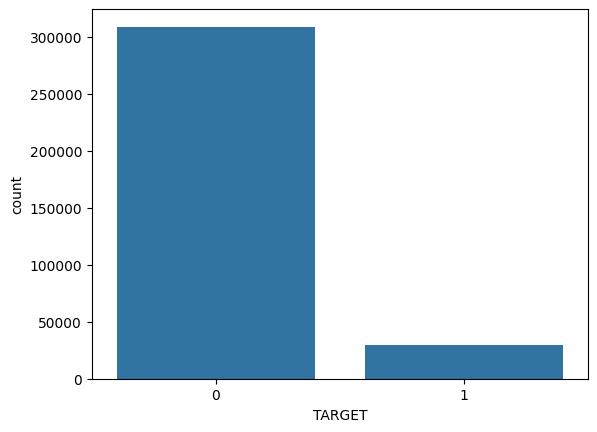

In [ ]:
sns.countplot(x="TARGET", data=df)
plt.show()

In [ ]:
print(f"I clienti presenti nel dataset che hanno un'alta affidabilità creditizia sono il {round(df['TARGET'].value_counts()[1]/df.shape[0]*100,2)}%")
print(f"I clienti presenti nel dataset che hanno una bassa affidabilità creditizia sono il {round(df['TARGET'].value_counts()[0]/df.shape[0]*100,2)}%")

Si può vedere un forte sbilanciamento nella variabile target che vogliamo studiare. Potrebbero essere utili metodi di Undersampling e/o Oversampling.

In [ ]:
#Adesso andiamo a visualizzare i grafici delle variabili qualitative con la variabile TARGET

plt.figure(figsize=(12,8))
sns.countplot(x="CODE_GENDER", hue="TARGET", data=df)
plt.title('CODE_GENDER VS TARGET')
plt.xlabel('(0:M, 1:F)')
plt.ylabel('Numero di Clienti')
plt.legend(title='TARGET')
plt.show()


plt.figure(figsize=(12,8))
sns.countplot(x="FLAG_OWN_CAR", hue="TARGET", data=df)
plt.title('FLAG_OWN_CAR VS TARGET')
plt.xlabel('(0:No, 1:Yes)')
plt.ylabel('Numero di Clienti')
plt.legend(title='TARGET')
plt.show()

plt.figure(figsize=(12,8))
sns.countplot(x="FLAG_OWN_REALTY", hue="TARGET", data=df)
plt.title('FLAG_OWN_REALTY VS TARGET')
plt.xlabel('(0:No, 1:Yes)')
plt.ylabel('Numero di Clienti')
plt.legend(title='TARGET')
plt.show()

plt.figure(figsize=(12,8))
sns.countplot(x="FLAG_MOBIL", hue="TARGET", data=df)
plt.title('FLAG_MOBIL VS TARGET')
plt.xlabel('(0:No, 1:Yes)')
plt.ylabel('Numero di Clienti')
plt.legend(title='TARGET')
plt.show()

plt.figure(figsize=(12,8))
sns.countplot(x="FLAG_WORK_PHONE", hue="TARGET", data=df)
plt.title('FLAG_WORK_PHONE VS TARGET')
plt.xlabel('(0:No, 1:Yes)')
plt.ylabel('Numero di Clienti')
plt.legend(title='TARGET')
plt.show()

plt.figure(figsize=(12,8))
sns.countplot(x="FLAG_PHONE", hue="TARGET", data=df)
plt.title('FLAG_PHONE VS TARGET')
plt.xlabel('(0:No, 1:Yes)')
plt.ylabel('Numero di Clienti')
plt.legend(title='TARGET')
plt.show()

plt.figure(figsize=(12,8))
sns.countplot(x="FLAG_EMAIL", hue="TARGET", data=df)
plt.title('FLAG_EMAIL VS TARGET')
plt.xlabel('(0:No, 1:Yes)')
plt.ylabel('Numero di Clienti')
plt.legend(title='TARGET')
plt.show()

plt.figure(figsize=(12,8))
sns.countplot(x="NAME_EDUCATION_TYPE", hue="TARGET", data=df)
plt.title('NAME_EDUCATION_TYPE VS TARGET')
plt.xlabel('(0:Lower secondary, 1:Secondary / secondary special, 2:Incomplete higher, 3:Higher education, 4:Academic degree)')
plt.ylabel('Numero di Clienti')
plt.legend(title='TARGET')
plt.show()

#boxplot delle variabili quantitative
plt.figure(figsize=(12,8))
sns.boxplot(x="TARGET", y="CNT_CHILDREN", data=df)
plt.title('CNT_CHILDREN VS TARGET')
plt.show()

plt.figure(figsize=(12,8))
sns.boxplot(x="TARGET", y="AMT_INCOME_TOTAL", data=df)
plt.title('AMT_INCOME_TOTAL VS TARGET')
plt.show()

plt.figure(figsize=(12,8))
sns.boxplot(x="TARGET", y="DAYS_BIRTH", data=df)
plt.title('DAYS_BIRTH VS TARGET')
plt.show()

plt.figure(figsize=(12,8))
sns.boxplot(x="TARGET", y="DAYS_EMPLOYED", data=df)
plt.title('DAYS_EMPLOYED VS TARGET')
plt.show()

plt.figure(figsize=(12,8))
sns.boxplot(x="TARGET", y="CNT_FAM_MEMBERS", data=df)
plt.title('CNT_FAM_MEMBERS VS TARGET')
plt.show()

Variabili Qualitative vs. TARGET:
* CODE_GENDER vs TARGET.
Questo grafico mostra la distribuzione per genere. Possiamo vedere che ci sono più clienti di genere femminile che maschile.
Il rapporto tra TARGET=0 e TARGET=1 appare simile in entrambi i gruppi e non si notano differenze nette.

* FLAG_OWN_CAR vs TARGET.
Questo grafico mostra l'affidabilità in base al possesso di un'auto.
I clienti senza un'auto sono in numero maggiore.
Anche qui non si notano differenze nette tra i due gruppi per quanto riguarda l'affidabilità creditizia.

* FLAG_OWN_REALTY vs TARGET.
Questo grafico mostra la distribuzione basata sul possesso di una proprietà immobiliare.
Il numero di clienti che possiedono una proprietà immobiliare è molto più alto di quelli che non la possiedono.
Sembra che la proporzione di clienti affidabili sia leggermente più alta tra chi non possiede una proprietà rispetto a chi la possiede.

* FLAG_WORK_PHONE vs TARGET.
Questo grafico analizza l'affidabilità in base al possesso di un telefono del lavoro.
La maggior parte dei clienti non ha un telefono del lavoro. Anche qui, le proporzioni di TARGET=0 e TARGET=1 sono molto simili tra i due gruppi.

* FLAG_PHONE vs TARGET.
Questo grafico mostra la distribuzione in base alla presenza di un numero di telefono fisso.
La maggior parte dei clienti non ha un telefono fisso.
Possiamo vedere che non c'è una chiara differenza tra i due gruppi.

* FLAG_EMAIL vs TARGET.
Questo grafico confronta l'affidabilità con il possesso di un'email.
La stragrande maggioranza dei clienti non ha un'email.
La proporzione di clienti TARGET=0 è schiacciante in entrambi i gruppi.
Possiamo dire che l'uso di un'email è un'informazione poco discriminante a causa del numero ridotto di clienti che ce l'hanno.

* NAME_EDUCATION_TYPE vs TARGET.
Questo grafico analizza la distribuzione dell'affidabilità per i diversi livelli di istruzione.
I livelli di istruzione 1 (secondaria) e 3 (istruzione superiore) sono i più popolari.
Purtroppo, la presenza di poche osservazioni per le altre categorie non permette di capire se effettivamente un'istruzione di livello superiore potrebbe portare più affidabilità creditizia.

Variabili Quantitative vs. TARGET (Boxplot):

* CNT_CHILDREN vs TARGET
Questo boxplot confronta la distribuzione del numero di figli.
La mediana per entrambi i gruppi è a 0. Tuttavia, la scatola del gruppo TARGET=1 è quasi completamente piatta, indicando che la stragrande maggioranza di questi clienti non ha figli. La scatola del gruppo TARGET=0 è leggermente più alta e mostra una maggiore variabilità.
In definitiva possiamo dire che sebbene la maggior parte dei clienti in entrambi i gruppi non abbia figli, il gruppo non affidabile è più eterogeneo, con una maggiore probabilità di avere uno o più figli e una presenza più significativa di outlier con un numero elevato di figli.

* AMT_INCOME_TOTAL vs TARGET
Questo boxplot confronta la distribuzione del reddito totale tra i clienti.
Le scatole e le mediane per entrambi i gruppi sono molto vicine, quasi sovrapposte, e si trovano a un livello di reddito basso.
Per la maggior parte dei clienti, il reddito non è un fattore discriminante significativo per l'affidabilità creditizia. Il grafico è dominato da molti outlier con redditi estremamente alti, ma questi non influenzano il valore mediano, che rimane simile per entrambi i gruppi.

* DAYS_BIRTH vs TARGET
Questo boxplot confronta la distribuzione dell'età tra i clienti. Ricordando che valori negativi più grandi indicano persone più anziane, possiamo vedere che la scatola del gruppo TARGET=1 è significativamente più in basso rispetto a quella del gruppo TARGET=0.
In definitiva possiamo dire che i clienti considerati affidabili tendono a essere più anziani rispetto ai clienti non affidabili.

* DAYS_EMPLOYED vs TARGET
Questo boxplot mostra la distribuzione dei giorni trascorsi dalla data di assunzione. Ricordiamoci che valori positivi indicano disoccupazione.
Possiamo vedere che la mediana in entrambi i gruppi è molto vicina a 0. Tuttavia, il gruppo TARGET=0 ha una distribuzione più ampia, con un gran numero di outlier estremi che indicano una lunga durata della disoccupazione.
La disoccupazione (o una lunga storia di disoccupazione) sembra essere un forte indicatore di rischio. I clienti non affidabili sono molto più propensi ad avere un valore alto per DAYS_EMPLOYED rispetto ai clienti affidabili.

* CNT_FAM_MEMBERS vs TARGET
Questo boxplot confronta il numero di membri della famiglia.
Come per il numero di figli, il numero di membri della famiglia non sembra essere un fattore molto discriminante, ma il gruppo affidabile mostra una maggiore uniformità.

In [ ]:
def plot_corr(df):
    corr = df.corr()

    sns.heatmap(corr,
                annot=True
                )
    plt.show()

In [ ]:
#grafichiamo la matrice di correlazione tra il Target e le variabili quantitative
plot_corr(df[["TARGET", "CNT_CHILDREN", "AMT_INCOME_TOTAL", "DAYS_BIRTH", "DAYS_EMPLOYED", "CNT_FAM_MEMBERS"]])

Le correlazioni tra la variabile TARGET e le altre feature sono tutte molto deboli, con valori vicini a zero. La correlazione più alta è con AMT_INCOME_TOTAL (0.22), ma anche questa è debole. Questo suggerisce che, prese singolarmente, le variabili CNT_CHILDREN, AMT_INCOME_TOTAL, DAYS_BIRTH, DAYS_EMPLOYED e CNT_FAM_MEMBERS non sono forti predittori del TARGET.

Per quanto riguarda invece le correlazione tra le feature si vedono correlazioni più interessanti.

* CNT_CHILDREN vs. CNT_FAM_MEMBERS (0.89): C'è una correlazione molto forte e positiva. Questo è logico: più figli hai, più membri della famiglia ci sono.

* DAYS_EMPLOYED (-0.61): Il valore negativo del coefficiente indica che all'aumentare di una variabile, l'altra diminuisce.
All'aumentare di DAYS_BIRTH (cioè, la persona diventa più anziana), il numero di giorni trascorsi dalla data di assunzione diminuisce (cioè, il numero di giorni è un valore negativo e diventa un numero più grande in valore assoluto, ad esempio, da -100 a -5000). Questo ha un senso logico perfetto: più una persona è anziana, più giorni ha passato lavorando.

* CNT_CHILDREN vs. DAYS_BIRTH (0.35): C'è una correlazione moderata e positiva.

* DAYS_EMPLOYED vs. AMT_INCOME_TOTAL (-0.14): C'è una correlazione debole e negativa

Per i modelli di classificazione che si basano su pesi o coefficienti per determinare l'importanza delle feature, la multicollinearità può causare problemi di instabilità e interpretabilità.

I modelli che si basano su decisioni o su distanze non sono significativamente influenzati dalla multicollinearità.

Noi però andremo ad analizzare anche modelli basati su pesi, come la Regressione Logistica, quindi andiamo a rimuovere quelle variabili che potrebbero dare problemi. Rimuoviamo anche FLAG_MOBIL in quanto poco significativa.

In [ ]:
df = df.drop(["CNT_FAM_MEMBERS", "FLAG_MOBIL", "DAYS_EMPLOYED"], axis=1)

In conclusione, l'esplorazione iniziale del dataset e l'analisi delle variabili quantitative e categoriche indicano che non esistono singole feature con un potere predittivo elevato per il nostro target.
Questo suggerisce che l'affidabilità creditizia non è determinata da un singolo fattore, piuttosto da relazioni complesse e interazioni tra più variabili (ad esempio, età, istruzione e tipo di reddito combinati).
Questo potrebbe giustificare l'esplorare modelli più avanzati come la Random Forest, che sono in grado di catturare efficacemente queste relazioni non lineari e interazioni, a differenza di un semplice modello lineare.

#Gestione dello Sbilanciamento delle Classi e creazione dei Modelli

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
X, y = df.drop("TARGET", axis=1), df["TARGET"]
X.shape, y.shape

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

In [ ]:
print(f"Il train set contiene {X_train.shape[0]} osservazioni con {X_train.shape[1]} features")
print(f"Il test set contiene {X_test.shape[0]} osservazioni con {X_test.shape[1]} features")

In [ ]:
ss = StandardScaler()

features_to_scale = ["CNT_CHILDREN", "AMT_INCOME_TOTAL", "DAYS_BIRTH"]

X_train[features_to_scale] = ss.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = ss.transform(X_test[features_to_scale])

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Proseguiamo testando e confrontando i modelli relativi a tecniche di bilanciamento diverso. Nello specifico si adotterà un modello di Regressione Logistica, ovvero un modello di classificazione, con metodi di bilanciamento delle classi (Class_Weight), UnderSampling e OverSampling, che ci permetterà di capire quali potrebbero essere le features più importanti. Successivamente si proveranno modelli Random Forest, modelli più complessi che ci permetteranno di ottenere probabilmente risultati migliori. La valutazione dei singoli e il confronto tra i vari modelli verrà fatto attraverso la cross-validation per essere più precisi possibile.

In [ ]:
preprocessor = ColumnTransformer(
    [("scaler", StandardScaler(), ["CNT_CHILDREN", "AMT_INCOME_TOTAL", "DAYS_BIRTH"])],
    remainder="passthrough"
)

# --- Metriche da Valutare ---
scoring = {
    'precision_1': make_scorer(precision_score, pos_label=1),
    'recall_1': make_scorer(recall_score, pos_label=1),
    'f1_1': make_scorer(f1_score, pos_label=1),
    'accuracy_1': make_scorer(accuracy_score),
}

#KFold per la cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [ ]:
#Pipelines per il modello di Regressione Logistica

pipe_no_balance = ImbPipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=RANDOM_SEED))
])

pipe_class_weight = ImbPipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced"))
])

pipe_under_sampling = ImbPipeline([
    ("preprocessor", preprocessor),
    ("under_sampler", RandomUnderSampler(sampling_strategy=0.4, random_state=RANDOM_SEED)),
    ("model", LogisticRegression(random_state=RANDOM_SEED))
])


pipe_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(sampling_strategy=0.20, random_state=RANDOM_SEED)),
    ("model", LogisticRegression(random_state=RANDOM_SEED))
])

pipe_under_over_sampling = ImbPipeline([
    ("preprocessor", preprocessor),
    ("over_sampler", SMOTE(sampling_strategy=.20, random_state=RANDOM_SEED)),
    ("under_sampler", RandomUnderSampler(sampling_strategy=0.40, random_state=RANDOM_SEED)),
    ("model", LogisticRegression(random_state=RANDOM_SEED))
])

#******************************************************************************#

#Pipelines per il modello Random Forest

pipe_rf_no_balance = ImbPipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_SEED))
])

pipe_rf_class_weight = ImbPipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_SEED, class_weight="balanced"))
])

pipe_rf_under_sampling = ImbPipeline([
    ("preprocessor", preprocessor),
    ("under_sampler", RandomUnderSampler(sampling_strategy=0.4, random_state=RANDOM_SEED)),
    ("model", RandomForestClassifier(random_state=RANDOM_SEED))
])

pipe_rf_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("over_sampler", SMOTE(sampling_strategy=0.20, random_state=RANDOM_SEED)),
    ("model", RandomForestClassifier(random_state=RANDOM_SEED))
])

pipe_rf_under_over_sampling = ImbPipeline([
    ("preprocessor", preprocessor),
    ("over_sampler", SMOTE(sampling_strategy=.20, random_state=RANDOM_SEED)),
    ("under_sampler", RandomUnderSampler(sampling_strategy=0.40, random_state=RANDOM_SEED)),
    ("model", RandomForestClassifier(random_state=RANDOM_SEED))
])

#******************************************************************************#


In [ ]:
#Valutazione modelli di Regressione Logistica

print("Valutazione modello senza bilanciamento")
lr_score_no_balance = cross_validate(pipe_no_balance, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in lr_score_no_balance.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("Valutazione modello con bilanciamento delle classi")
lr_score_class_weight = cross_validate(pipe_class_weight, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in lr_score_class_weight.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("Valutazione modello con Undersampling")
lr_score_under_sampling = cross_validate(pipe_under_sampling, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in lr_score_under_sampling.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("Valutazione modello con SMOTE")
lr_score_smote = cross_validate(pipe_smote, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in lr_score_smote.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("Valutazione modello con Undersampling e Oversampling")
lr_score_under_over_sampling = cross_validate(pipe_under_over_sampling, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in lr_score_under_over_sampling.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

In [ ]:
#Valutazione modelli Random Forest
print("Valutazione modello senza bilanciamento")
rf_score_no_balance = cross_validate(pipe_rf_no_balance, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in rf_score_no_balance.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("Valutazione modello con bilanciamento delle classi")
rf_score_class_weight = cross_validate(pipe_rf_class_weight, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in rf_score_class_weight.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("Valutazione modello con Undersampling")
rf_score_under_sampling = cross_validate(pipe_rf_under_sampling, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in rf_score_under_sampling.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("Valutazione modello con SMOTE")
rf_score_smote = cross_validate(pipe_rf_smote, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in rf_score_smote.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)

print("Valutazione modello con Undersampling e Oversampling")
rf_score_under_over_sampling = cross_validate(pipe_rf_under_over_sampling, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
for metric_name, values in rf_score_under_over_sampling.items():
    print(f"{metric_name}: {values.mean():.4f} (+/- {values.std():.4f}) \n")
print("-" * 50)


Tutto sommato dalla cross-validation il modello più semplice, quello di Regressione Logistica con bilanciamento Class Weight, sembra comportarsi abbastanza bene per quanto riguarda la Recall. I modelli Random Forest sembrano avere ottimi risultati ma tendono ad overfittare. Cercheremo di risolvere questo problema nella fase di tuning degli iperparametri.

Ovviamente i modelli che si andranno a testare sono in base alle metriche di valutazione più importanti per la casistica in questione.

Per un dataset sbilanciato, l'accuratezza (accuracy) è una metrica fuorviante. Concentriamoci invece su Precision e Recall, infatti:

* FN - Falso Negativo: Il modello predice che il cliente è negativo (classe 0 - inaffidabile), ma in realtà è positivo (classe 1 - affidabile).
    * Errore: Neghi un prestito a un cliente che lo avrebbe ripagato.

    * Conseguenza: Perdi un'opportunità di business.

* FP - Falso Positivo: Il modello predice che il cliente è positivo (classe 1 - affidabile), ma in realtà è negativo (classe 0 - inaffidabile).

    * Errore: Concedi un prestito a un cliente che non lo ripagherà.

    * Conseguenza: Subisci una perdita finanziaria (default).

Inoltre utilizzeremo anche la Curva AUC-ROC (Area Under the Curve - Receiver Operating Characteristic): Fornisce una valutazione complessiva della capacità del modello di distinguere tra le classi.

In [ ]:
#Proviamo il modello di regressione Logistica con il bilanciamento delle classi

model = LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced")
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)

y_pred_test= model.predict(X_test)
y_proba_test = model.predict_proba(X_test)

print(classification_report(y_train, y_pred_train))
print("-" * 50)
print(classification_report(y_test, y_pred_test))
print("-" * 50)

Possiamo visualizzare la Curva ROC e capire se poter bilanciare un po' Precison e Recall, andando a modificare la decision boundary

In [ ]:
RocCurveDisplay.from_estimator(model, X_test, y_test, name="Classificatore per affidabilità creditizia")
plt.plot([0,1], [0,1], "k--", label="Modello Casuale (AUC = 0.5)")
plt.title("Curva ROC (test-set)")

#plot di una linea verticale che passa dove il trade off tra FPR e TPR è migliore
plt.vlines(x=0.5, ymin=0, ymax=1, linestyles='dashed', colors='red')

plt.legend()
plt.show()

In questa casista non conviene modificare la decision boundary andando a cambiare le probabilità.

Possiamo anche visualizzare i coefficienti del modello, che ci permettono di capire quali sono le feature più importanti, e, quindi, nel caso che a un cliente venga negata la carta di credito, si può dare una motivazione e far capire su cosa "puntare".

In [ ]:
feature_importance = pd.DataFrame({'feature': X_train.columns, 'coefficient': model.coef_[0]})
feature_importance['abs_coefficient'] = np.abs(feature_importance['coefficient'])

feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

print(feature_importance)

Proviamo adesso il modello Random Forest che sembra migliore, ovvero quello che unisce l'oversampling con l'undersampling.

In [ ]:
model2 = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1, n_estimators=1000, max_depth=5, min_samples_leaf=100, min_samples_split=5)

over = SMOTE(sampling_strategy=0.20, random_state=RANDOM_SEED)
X_over, y_over = over.fit_resample(X_train, y_train)

under = RandomUnderSampler(random_state=RANDOM_SEED)
X_under, y_under = under.fit_resample(X_over, y_over)


print(Counter(y_train))
print(Counter(y_over))
print(Counter(y_under))

model2.fit(X_under, y_under)

In [ ]:
y_pred_train = model2.predict(X_train)
y_proba_train = model2.predict_proba(X_train)

y_pred_test= model2.predict(X_test)
y_proba_test = model2.predict_proba(X_test)

print(classification_report(y_train, y_pred_train))
print("-" * 50)
print(classification_report(y_test, y_pred_test))

In [ ]:
def plot_confusion_matrix(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    df_cm = pd.DataFrame(cm,
                         index=["Negative", "Positive"],
                         columns=["Predicted Negative", "Predicted Positive"])
    sns.heatmap(df_cm, annot=True, fmt="d")
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    plt.text(0.25, -0.1, f"Precision: {prec:.2f}", ha="center")
    plt.text(1.2, -0.1, f"Recall: {rec:.2f}", ha="center")
    plt.show()

plot_confusion_matrix(y_test, y_pred_test)

Possiamo provare anche qui a bilanciare precison e recall, ovviamente tenendo la recall abbastanza alta.

In [ ]:
RocCurveDisplay.from_estimator(model2, X_test, y_test, name="Classificatore per affidabilità creditizia")
plt.plot([0,1], [0,1], "k--", label="Modello Casuale (AUC = 0.5)")
plt.title("Curva ROC (test-set)")

plt.legend()
plt.show()

In [ ]:
y_pred_test = np.where(y_proba_test[:,1] > 0.72, 1, 0)
print(classification_report(y_test, y_pred_test))

In [ ]:
feature_importance = pd.DataFrame({'feature': X_train.columns, 'importance': model2.feature_importances_})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

print(feature_importance)

Al termine di questo progetto, dopo aver implementato diverse strategie di preprocessing, ribilanciamento e ottimizzazione del modello Random Forest, abbiamo osservato che le performance del modello sembrano raggiungere un limite intrinseco, dettato dalla natura dei dati attuali.

Il modello ha mostrato un'eccellente capacità discriminatoria, confermata da un ROC AUC di 0.95. Sul test set, il modello ha ottenuto un F1-score di 0.63, una Precisione di 0.45-0.47 e una Recall di 0.95-0.99.

La saturazione delle performance è da ricondursi a fattori specifici del dataset, già individuati nelle analisi iniziali, tra cui l'estremo sbilanciamento delle classi, il debole impatto predittivo delle singole feature e la complessità intrinseca del problema stesso.

È importante sottolineare che la bassa precisione, che era la metrica da preferire per minimizzare i default, indica che il modello etichetta come 'affidabili' un numero significativo di clienti che non lo sono. Questo è un fattore di saturazione delle performance.

Per il futuro, la strategia più efficace sarà quella di integrare nuovi dati, sfruttando le informazioni chiave ottenute da questo modello (come l'età, l'istruzione e il tipo di reddito) per costruire un modello progressivamente più performante. L'integrazione di dati esterni, come la cronologia creditizia, potrebbe essere la chiave per superare i limiti attuali.